In [13]:
# Import library

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Library berhasil diimport!")

Library berhasil diimport!


In [14]:
# Membaca dataset

df = pd.read_csv(
    '/content/dataset_garis_kemiskinan_rapi (1).csv',
    sep=';'
)

print("Dataset berhasil dibaca!")

Dataset berhasil dibaca!


In [15]:
# Menampilkan 5 data pertama

df.head()

,Provinsi,Tahun,Periode,Wilayah,Komponen,Nilai_GK
0,ACEH,2013,Maret,Perdesaan,Total,319416.0
1,ACEH,2013,Maret,Perkotaan,Total,359217.0
2,ACEH,2013,September,Perdesaan,Total,337962.0
3,ACEH,2013,September,Perkotaan,Total,374261.0
4,ACEH,2014,Maret,Perdesaan,Total,350204.0


In [16]:
# Mengecek jumlah baris dan kolom

print("Jumlah baris :", df.shape[0])
print("Jumlah kolom :", df.shape[1])
print("Ukuran dataset :", df.shape)

Jumlah baris : 5261
Jumlah kolom : 6
Ukuran dataset : (5261, 6)


In [17]:
# Menampilkan nama kolom

print("Nama kolom:")
print(df.columns.tolist())

Nama kolom:
['Provinsi', 'Tahun', 'Periode', 'Wilayah', 'Komponen', 'Nilai_GK']


In [18]:
# Informasi dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5261 entries, 0 to 5260
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Provinsi  5261 non-null   object 
 1   Tahun     5261 non-null   int64  
 2   Periode   5261 non-null   object 
 3   Wilayah   5261 non-null   object 
 4   Komponen  5261 non-null   object 
 5   Nilai_GK  5261 non-null   float64
dtypes: float64(1), int64(1), object(4)
memory usage: 246.7+ KB


In [19]:
# Statistik deskriptif

df.describe()

,Tahun,Nilai_GK
count,5261.000000,5261.000000
mean,2018.244250,303904.185516
std,2.491855,158176.024903
min,2013.000000,48561.000000
25%,2016.000000,144674.000000
50%,2018.000000,313294.000000
75%,2020.000000,410188.000000
max,2022.000000,872843.000000


In [20]:
# Mengecek missing value

print("Jumlah missing value setiap kolom:")
print(df.isnull().sum())

Jumlah missing value setiap kolom:
Provinsi    0
Tahun       0
Periode     0
Wilayah     0
Komponen    0
Nilai_GK    0
dtype: int64


In [21]:
# Mengecek data duplikat

jumlah_duplikat = df.duplicated().sum()

print("Jumlah data duplikat:", jumlah_duplikat)

Jumlah data duplikat: 0


In [22]:
# Melihat jumlah data unik pada setiap kolom

print("Jumlah provinsi :", df['Provinsi'].nunique())
print("Jumlah tahun   :", df['Tahun'].nunique())
print("Periode        :", df['Periode'].unique())
print("Wilayah        :", df['Wilayah'].unique())
print("Komponen       :", df['Komponen'].unique())

Jumlah provinsi : 35
Jumlah tahun   : 10
Periode        : ['Maret' 'September']
Wilayah        : ['Perdesaan' 'Perkotaan' 'Perkotaan dan Perdesaan']
Komponen       : ['Total' 'Makanan' 'Non-Makanan']


In [23]:
# Melihat tahun yang tersedia

print("Tahun paling awal :", df['Tahun'].min())
print("Tahun paling akhir:", df['Tahun'].max())
print("\nDaftar tahun:")
print(sorted(df['Tahun'].unique()))

Tahun paling awal : 2013
Tahun paling akhir: 2022

Daftar tahun:
[np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]


In [24]:
# Rata-rata garis kemiskinan berdasarkan tahun

rata_tahun = df.groupby('Tahun')['Nilai_GK'].mean()

print(rata_tahun)

Tahun
2013    298541.362963
2014    325091.679104
2015    241672.544872
2016    257629.306090
2017    273818.554487
2018    291275.166667
2019    311481.216346
2020    329148.182692
2021    346235.067308
2022    376583.793269
Name: Nilai_GK, dtype: float64


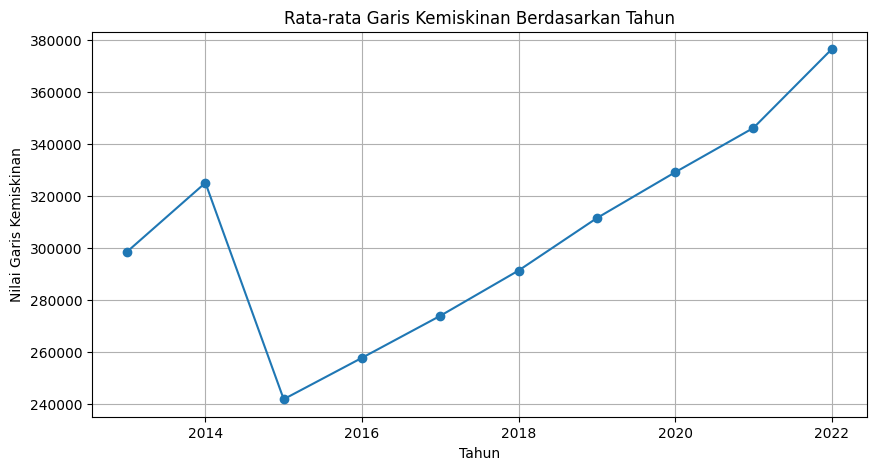

In [25]:
# Grafik rata-rata garis kemiskinan berdasarkan tahun

plt.figure(figsize=(10, 5))

plt.plot(
    rata_tahun.index,
    rata_tahun.values,
    marker='o'
)

plt.title('Rata-rata Garis Kemiskinan Berdasarkan Tahun')
plt.xlabel('Tahun')
plt.ylabel('Nilai Garis Kemiskinan')
plt.grid(True)

plt.show()

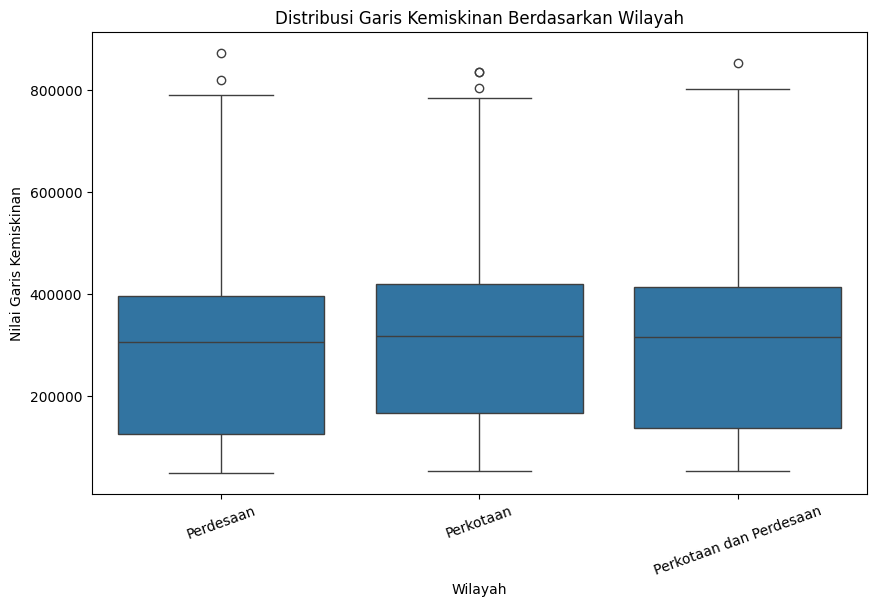

In [26]:
# Distribusi garis kemiskinan berdasarkan wilayah

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x='Wilayah',
    y='Nilai_GK'
)

plt.title('Distribusi Garis Kemiskinan Berdasarkan Wilayah')
plt.xlabel('Wilayah')
plt.ylabel('Nilai Garis Kemiskinan')
plt.xticks(rotation=20)

plt.show()

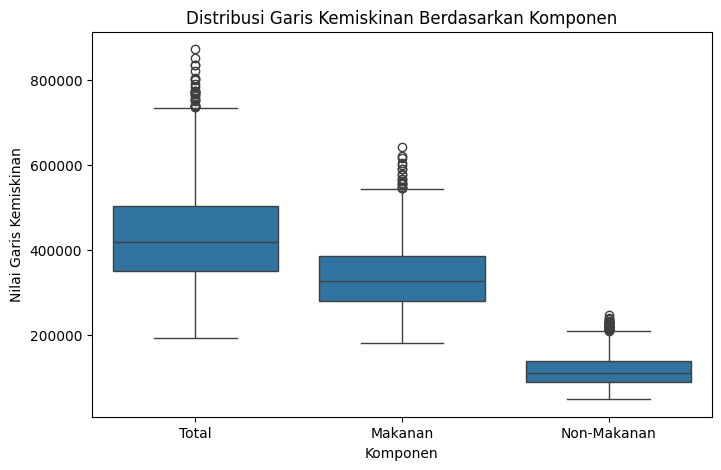

In [27]:
# Distribusi garis kemiskinan berdasarkan komponen

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='Komponen',
    y='Nilai_GK'
)

plt.title('Distribusi Garis Kemiskinan Berdasarkan Komponen')
plt.xlabel('Komponen')
plt.ylabel('Nilai Garis Kemiskinan')

plt.show()

In [28]:
# Rata-rata garis kemiskinan setiap provinsi

rata_provinsi = (
    df.groupby('Provinsi')['Nilai_GK']
    .mean()
    .sort_values(ascending=False)
)

print(rata_provinsi)

Provinsi
KEP. BANGKA BELITUNG    442526.486842
KALIMANTAN UTARA        416861.381944
DKI JAKARTA             414747.752475
KALIMANTAN TIMUR        405542.888158
KEP. RIAU               380420.434211
PAPUA BARAT             378025.421053
PAPUA                   353854.552632
MALUKU                  339641.644737
RIAU                    339323.907895
SUMATERA BARAT          336896.848684
BENGKULU                335782.552632
ACEH                    328787.157895
SUMATERA UTARA          308304.644737
JAMBI                   306920.677632
KALIMANTAN SELATAN      303203.335526
BANTEN                  299641.585526
KALIMANTAN TENGAH       296581.901316
SULAWESI TENGAH         296578.993421
MALUKU UTARA            294002.026316
LAMPUNG                 289832.855263
KALIMANTAN BARAT        288014.210526
INDONESIA               280827.552632
DI YOGYAKARTA           280321.105263
SUMATERA SELATAN        278192.934211
BALI                    266290.059211
NUSA TENGGARA TIMUR     264361.703947
JAW

In [29]:
# Menentukan fitur (X) dan target (y)

X = df[
    ['Provinsi', 'Tahun', 'Periode', 'Wilayah', 'Komponen']
]

y = df['Nilai_GK']

print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Fitur (X):
  Provinsi  Tahun    Periode    Wilayah Komponen
0     ACEH   2013      Maret  Perdesaan    Total
1     ACEH   2013      Maret  Perkotaan    Total
2     ACEH   2013  September  Perdesaan    Total
3     ACEH   2013  September  Perkotaan    Total
4     ACEH   2014      Maret  Perdesaan    Total

Target (y):
0    319416.0
1    359217.0
2    337962.0
3    374261.0
4    350204.0
Name: Nilai_GK, dtype: float64


In [30]:
# Menentukan fitur numerik dan kategorikal

fitur_numerik = ['Tahun']

fitur_kategorikal = [
    'Provinsi',
    'Periode',
    'Wilayah',
    'Komponen'
]

print("Fitur numerik:", fitur_numerik)
print("Fitur kategorikal:", fitur_kategorikal)

Fitur numerik: ['Tahun']
Fitur kategorikal: ['Provinsi', 'Periode', 'Wilayah', 'Komponen']


In [31]:
# Preprocessing data kategorikal

preprocessor = ColumnTransformer(
    transformers=[
        (
            'kategori',
            OneHotEncoder(handle_unknown='ignore'),
            fitur_kategorikal
        )
    ],
    remainder='passthrough'
)

print("Preprocessing berhasil dibuat!")

Preprocessing berhasil dibuat!


In [32]:
# Membagi dataset berdasarkan tahun

train_data = df[df['Tahun'] <= 2020].copy()
test_data = df[df['Tahun'] > 2020].copy()

print("Data training:", train_data.shape)
print("Data testing :", test_data.shape)

Data training: (4013, 6)
Data testing : (1248, 6)


In [33]:
# Menentukan data training dan testing

X_train = train_data[
    ['Provinsi', 'Tahun', 'Periode', 'Wilayah', 'Komponen']
]

y_train = train_data['Nilai_GK']

X_test = test_data[
    ['Provinsi', 'Tahun', 'Periode', 'Wilayah', 'Komponen']
]

y_test = test_data['Nilai_GK']

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (4013, 5)
y_train: (4013,)
X_test : (1248, 5)
y_test : (1248,)


In [34]:
# Membuat model Linear Regression

model_lr = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        ('model', LinearRegression())
    ]
)

# Melatih model
model_lr.fit(X_train, y_train)

print("Model Linear Regression berhasil dilatih!")

Model Linear Regression berhasil dilatih!


In [35]:
# Melakukan prediksi dengan Linear Regression

y_pred_lr = model_lr.predict(X_test)

print("Prediksi berhasil dilakukan!")
print(y_pred_lr[:10])

Prediksi berhasil dilakukan!
[396853.84193752 191019.86277086 501712.56574591 416093.37285928
 210259.39369261 520952.09666767 408166.0167029  202332.03753623
 513024.74051128 405740.47419114]


In [36]:
# Evaluasi Linear Regression

mae_lr = mean_absolute_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

r2_lr = r2_score(y_test, y_pred_lr)

print("HASIL EVALUASI LINEAR REGRESSION")
print("----------------------------------")
print("MAE  :", mae_lr)
print("RMSE :", rmse_lr)
print("R²   :", r2_lr)

HASIL EVALUASI LINEAR REGRESSION
----------------------------------
MAE  : 40998.51784977877
RMSE : 53579.29324470242
R²   : 0.9156231802560924


In [37]:
# Membuat model Random Forest

model_rf = Pipeline(
    steps=[
        ('preprocessing', preprocessor),
        (
            'model',
            RandomForestRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

# Melatih model
model_rf.fit(X_train, y_train)

print("Model Random Forest berhasil dilatih!")

Model Random Forest berhasil dilatih!


In [38]:
# Melakukan prediksi dengan Random Forest

y_pred_rf = model_rf.predict(X_test)

print("Prediksi berhasil dilakukan!")
print(y_pred_rf[:10])

Prediksi berhasil dilakukan!
[396105.81  114271.245 509210.415 397787.525 142091.235 536607.42
 396597.685 124182.67  520363.515 396737.68 ]


In [39]:
# Evaluasi Random Forest

mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("HASIL EVALUASI RANDOM FOREST")
print("-----------------------------")
print("MAE  :", mae_rf)
print("RMSE :", rmse_rf)
print("R²   :", r2_rf)

HASIL EVALUASI RANDOM FOREST
-----------------------------
MAE  : 33048.93141025642
RMSE : 41938.567810982786
R²   : 0.9483040665222906


In [40]:
# Membandingkan hasil kedua model

hasil_model = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        mae_lr,
        mae_rf
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf
    ],
    'R2': [
        r2_lr,
        r2_rf
    ]
})

hasil_model

,Model,MAE,RMSE,R2
0,Linear Regression,40998.51785,53579.293245,0.915623
1,Random Forest,33048.93141,41938.567811,0.948304


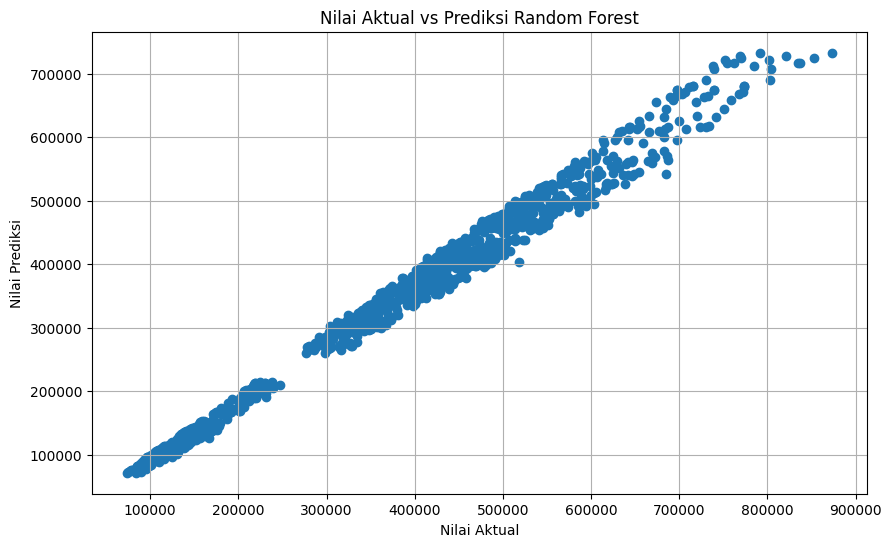

In [41]:
# Grafik nilai aktual vs nilai prediksi

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred_rf
)

plt.xlabel('Nilai Aktual')
plt.ylabel('Nilai Prediksi')
plt.title('Nilai Aktual vs Prediksi Random Forest')

plt.grid(True)

plt.show()

In [42]:
# Membuat tabel hasil prediksi

hasil_prediksi = X_test.copy()

hasil_prediksi['Nilai_Aktual'] = y_test.values
hasil_prediksi['Nilai_Prediksi'] = y_pred_rf

hasil_prediksi.head(20)

,Provinsi,Tahun,Periode,Wilayah,Komponen,Nilai_Aktual,Nilai_Prediksi
116,ACEH,2021,Maret,Perdesaan,Makanan,406917.0,396105.810
117,ACEH,2021,Maret,Perdesaan,Non-Makanan,122118.0,114271.245
118,ACEH,2021,Maret,Perdesaan,Total,529035.0,509210.415
119,ACEH,2021,Maret,Perkotaan,Makanan,418047.0,397787.525
120,ACEH,2021,Maret,Perkotaan,Non-Makanan,147729.0,142091.235
121,ACEH,2021,Maret,Perkotaan,Total,565776.0,536607.420
122,ACEH,2021,Maret,Perkotaan dan Perdesaan,Makanan,410420.0,396597.685
123,ACEH,2021,Maret,Perkotaan dan Perdesaan,Non-Makanan,130689.0,124182.670
124,ACEH,2021,Maret,Perkotaan dan Perdesaan,Total,541109.0,520363.515
125,ACEH,2021,September,Perdesaan,Makanan,414738.0,396737.680
